In [ ]:
import pandas as pd

# Load datasets
indian = pd.read_excel("IN_Data.xlsx")
japanese = pd.read_excel("JPN Data (1).xlsx")

# Display first 5 rows
print("INDIAN DATASET")
display(indian.head())

print("JAPANESE DATASET")
display(japanese.head())

INDIAN DATASET


,ID,CURR_AGE,GENDER,ANN_INCOME,DT_MAINT
0,20710B05XL,54,M,1425390,2018-04-20
1,89602T51HX,47,M,1678954,2018-06-08
2,70190Z52IP,60,M,931624,2017-07-31
3,25623V15MU,55,F,1106320,2017-07-31
4,36230I68CE,32,F,748465,2019-01-27


JAPANESE DATASET


,ID,CURR_AGE,GENDER,ANN_INCOME,AGE_CAR,PURCHASE
0,00001Q15YJ,50,M,445344.000000,439,0
1,00003I71CQ,35,M,107634.000000,283,0
2,00003N47FS,59,F,502786.666667,390,1
3,00005H41DE,43,M,585664.000000,475,0
4,00007E17UM,39,F,705722.666667,497,1


In [ ]:
print("Indian Dataset Shape:", indian.shape)
print("Japanese Dataset Shape:", japanese.shape)

print("\nIndian Columns:")
print(indian.columns.tolist())

print("\nJapanese Columns:")
print(japanese.columns.tolist())

Indian Dataset Shape: (70000, 5)
Japanese Dataset Shape: (40000, 6)

Indian Columns:
['ID', 'CURR_AGE', 'GENDER', 'ANN_INCOME', 'DT_MAINT']

Japanese Columns:
['ID', 'CURR_AGE', 'GENDER', 'ANN_INCOME', 'AGE_CAR', 'PURCHASE']


In [ ]:
print("INDIAN MISSING VALUES")
print(indian.isnull().sum())

print("\nJAPANESE MISSING VALUES")
print(japanese.isnull().sum())

INDIAN MISSING VALUES
ID            0
CURR_AGE      0
GENDER        0
ANN_INCOME    0
DT_MAINT      0
dtype: int64

JAPANESE MISSING VALUES
ID            0
CURR_AGE      0
GENDER        0
ANN_INCOME    0
AGE_CAR       0
PURCHASE      0
dtype: int64


In [ ]:
print("Indian duplicates:", indian.duplicated().sum())
print("Japanese duplicates:", japanese.duplicated().sum())

Indian duplicates: 0
Japanese duplicates: 0


In [ ]:
print("JAPANESE DATASET SUMMARY")
display(japanese.describe())

JAPANESE DATASET SUMMARY


,CURR_AGE,ANN_INCOME,AGE_CAR,PURCHASE
count,40000.00000,40000.000000,40000.000000,40000.000000
mean,44.99745,359398.878050,359.080250,0.575775
std,11.82008,175109.262950,203.063724,0.494231
min,25.00000,70089.000000,1.000000,0.000000
25%,35.00000,219766.000000,235.000000,0.000000
50%,45.00000,337656.833333,331.000000,1.000000
75%,55.00000,464261.000000,444.000000,1.000000
max,65.00000,799970.666667,1020.000000,1.000000


In [ ]:
print("PURCHASE COUNTS")
print(japanese["PURCHASE"].value_counts())

print("\nPURCHASE PERCENTAGE")
print(japanese["PURCHASE"].value_counts(normalize=True) * 100)

PURCHASE COUNTS
PURCHASE
1    23031
0    16969
Name: count, dtype: int64

PURCHASE PERCENTAGE
PURCHASE
1    57.5775
0    42.4225
Name: proportion, dtype: float64


In [ ]:
print("GENDER DISTRIBUTION - JAPAN")
print(japanese["GENDER"].value_counts())

print("\nGENDER DISTRIBUTION - INDIA")
print(indian["GENDER"].value_counts())

GENDER DISTRIBUTION - JAPAN
GENDER
M    22285
F    17715
Name: count, dtype: int64

GENDER DISTRIBUTION - INDIA
GENDER
M    35029
F    34971
Name: count, dtype: int64


In [ ]:
print("INDIAN DATASET SUMMARY")
display(indian.describe())

INDIAN DATASET SUMMARY


,CURR_AGE,ANN_INCOME,DT_MAINT
count,70000.000000,7.000000e+04,70000
mean,44.995314,1.148679e+06,2018-06-28 16:10:28.662856960
min,25.000000,3.000330e+05,2016-09-14 00:00:00
25%,35.000000,8.568238e+05,2018-03-15 00:00:00
50%,45.000000,1.125152e+06,2018-07-26 00:00:00
75%,55.000000,1.438676e+06,2018-12-24 00:00:00
max,65.000000,1.999989e+06,2019-06-30 00:00:00
std,11.822122,3.994505e+05,NaN


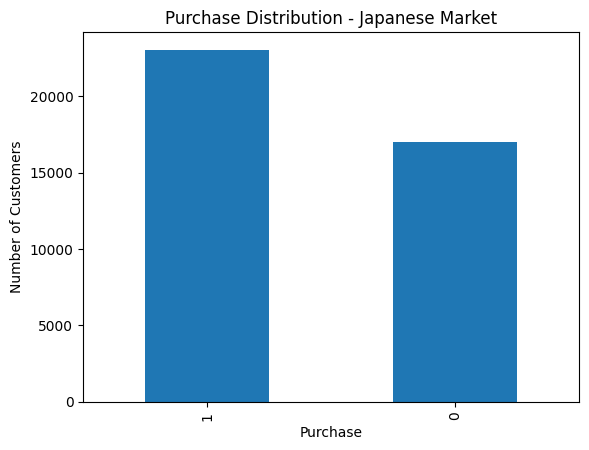

In [ ]:
import matplotlib.pyplot as plt

japanese["PURCHASE"].value_counts().plot(kind="bar")

plt.title("Purchase Distribution - Japanese Market")
plt.xlabel("Purchase")
plt.ylabel("Number of Customers")
plt.show()

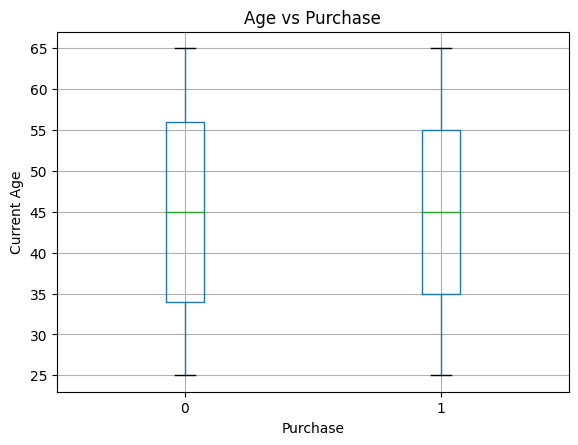

In [ ]:
japanese.boxplot(column="CURR_AGE", by="PURCHASE")

plt.title("Age vs Purchase")
plt.suptitle("")
plt.xlabel("Purchase")
plt.ylabel("Current Age")
plt.show()

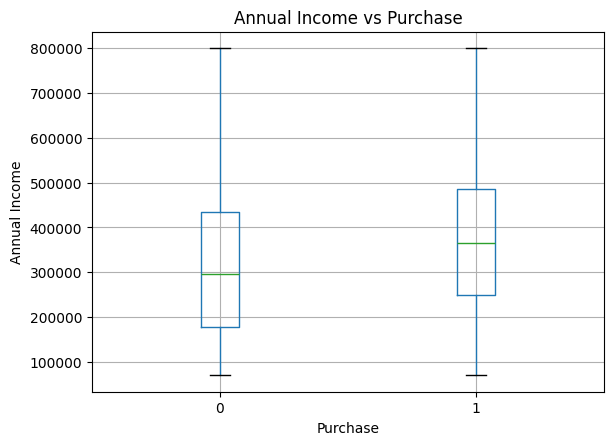

In [ ]:
japanese.boxplot(column="ANN_INCOME", by="PURCHASE")

plt.title("Annual Income vs Purchase")
plt.suptitle("")
plt.xlabel("Purchase")
plt.ylabel("Annual Income")
plt.show()

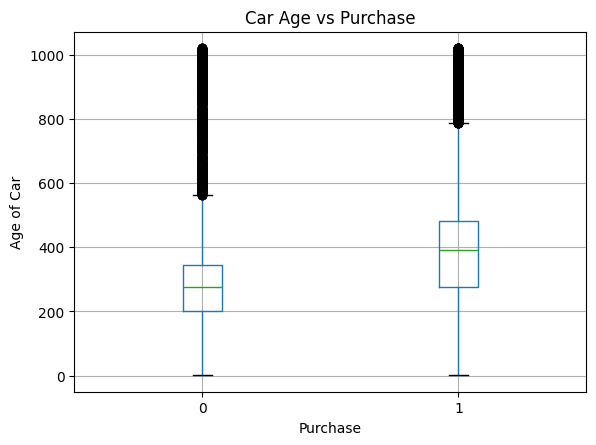

In [ ]:
japanese.boxplot(column="AGE_CAR", by="PURCHASE")

plt.title("Car Age vs Purchase")
plt.suptitle("")
plt.xlabel("Purchase")
plt.ylabel("Age of Car")
plt.show()

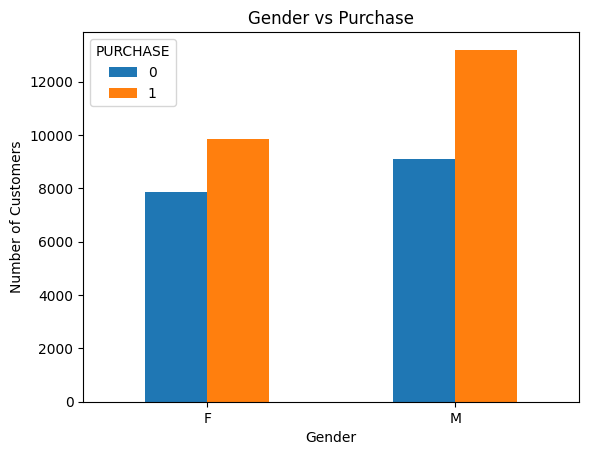

In [ ]:
pd.crosstab(
    japanese["GENDER"],
    japanese["PURCHASE"]
).plot(kind="bar")

plt.title("Gender vs Purchase")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [ ]:
X = japanese[["CURR_AGE", "GENDER", "ANN_INCOME", "AGE_CAR"]]
y = japanese["PURCHASE"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,CURR_AGE,GENDER,ANN_INCOME,AGE_CAR
0,50,M,445344.000000,439
1,35,M,107634.000000,283
2,59,F,502786.666667,390
3,43,M,585664.000000,475
4,39,F,705722.666667,497



Target:


,PURCHASE
0,0
1,0
2,1
3,0
4,1


In [ ]:
X = pd.get_dummies(X, columns=["GENDER"], drop_first=True)

print(X.head())
print("\nColumns:")
print(X.columns.tolist())

   CURR_AGE     ANN_INCOME  AGE_CAR  GENDER_M
0        50  445344.000000      439      True
1        35  107634.000000      283      True
2        59  502786.666667      390     False
3        43  585664.000000      475      True
4        39  705722.666667      497     False

Columns:
['CURR_AGE', 'ANN_INCOME', 'AGE_CAR', 'GENDER_M']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (32000, 4)
Testing data: (8000, 4)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (32000, 4)
Testing data: (8000, 4)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")

Scaling completed successfully!


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

model.fit(X_train_scaled, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [ ]:
y_pred = model.predict(X_test_scaled)

y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("First 10 Predictions:")
print(y_pred[:10])

print("\nFirst 10 Probabilities:")
print(y_prob[:10])

First 10 Predictions:
[0 1 1 0 1 1 1 1 1 1]

First 10 Probabilities:
[0.40220769 0.5771727  0.95617586 0.42917206 0.56597427 0.60616894
 0.74057536 0.72852347 0.5576091  0.76307019]


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("===== MODEL PERFORMANCE =====")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

===== MODEL PERFORMANCE =====
Accuracy : 0.6707
Precision: 0.689
Recall   : 0.7803
F1 Score : 0.7318
ROC-AUC  : 0.7221


Confusion Matrix:
[[1772 1622]
 [1012 3594]]


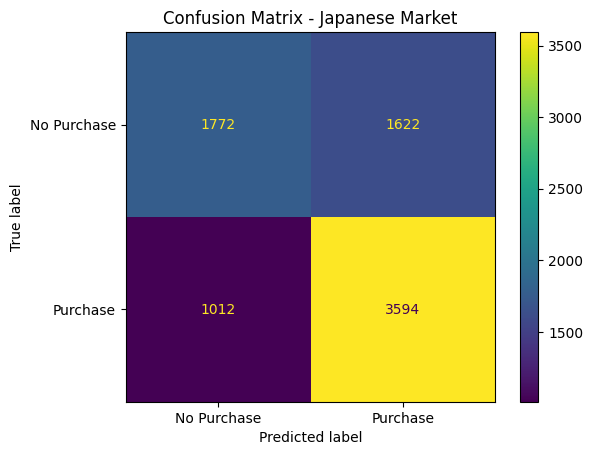

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Purchase", "Purchase"]
).plot()

plt.title("Confusion Matrix - Japanese Market")
plt.show()

In [ ]:
# Get model coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Odds_Ratio"] = coefficients["Coefficient"].apply(lambda x: __import__("math").exp(x))

display(coefficients)

,Feature,Coefficient,Odds_Ratio
0,CURR_AGE,-0.142280,0.867378
1,ANN_INCOME,0.427598,1.533570
2,AGE_CAR,0.856341,2.354529
3,GENDER_M,0.112826,1.119438


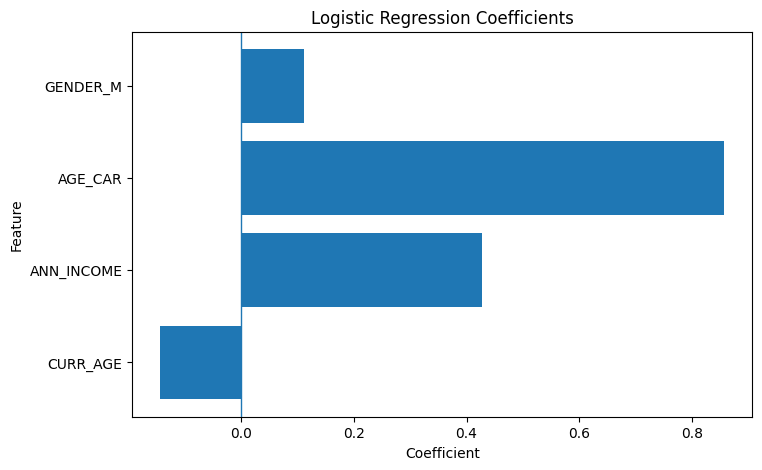

In [ ]:
plt.figure(figsize=(8,5))

plt.barh(coefficients["Feature"], coefficients["Coefficient"])

plt.axvline(0, linewidth=1)

plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

In [ ]:
import math

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Odds_Ratio"] = coefficients["Coefficient"].apply(math.exp)

display(coefficients)

,Feature,Coefficient,Odds_Ratio
0,CURR_AGE,-0.142280,0.867378
1,ANN_INCOME,0.427598,1.533570
2,AGE_CAR,0.856341,2.354529
3,GENDER_M,0.112826,1.119438


In [ ]:
# Prepare Indian dataset for prediction

india_X = indian[["CURR_AGE", "GENDER", "ANN_INCOME"]].copy()

# Convert Gender into numeric form
india_X = pd.get_dummies(india_X, columns=["GENDER"], drop_first=True)

print("Indian prediction features:")
display(india_X.head())

print("Columns:")
print(india_X.columns.tolist())

Indian prediction features:


,CURR_AGE,ANN_INCOME,GENDER_M
0,54,1425390,True
1,47,1678954,True
2,60,931624,True
3,55,1106320,False
4,32,748465,False


Columns:
['CURR_AGE', 'ANN_INCOME', 'GENDER_M']


In [ ]:
# Convert maintenance date to datetime
indian["DT_MAINT"] = pd.to_datetime(indian["DT_MAINT"])

# Use a fixed reference date for reproducibility
reference_date = pd.Timestamp("2025-01-01")

# Estimate car age in days
indian["AGE_CAR"] = (
    reference_date - indian["DT_MAINT"]
).dt.days

# Check the result
display(indian[["CURR_AGE", "GENDER", "ANN_INCOME", "DT_MAINT", "AGE_CAR"]].head())

print(indian["AGE_CAR"].describe())

,CURR_AGE,GENDER,ANN_INCOME,DT_MAINT,AGE_CAR
0,54,M,1425390,2018-04-20,2448
1,47,M,1678954,2018-06-08,2399
2,60,M,931624,2017-07-31,2711
3,55,F,1106320,2017-07-31,2711
4,32,F,748465,2019-01-27,2166


count    70000.000000
mean      2378.326057
std        241.999792
min       2012.000000
25%       2200.000000
50%       2351.000000
75%       2484.000000
max       3031.000000
Name: AGE_CAR, dtype: float64


In [ ]:
# Prepare Indian features in the same order as the Japanese model

india_X = indian[[
    "CURR_AGE",
    "GENDER",
    "ANN_INCOME",
    "AGE_CAR"
]].copy()

# Encode gender
india_X = pd.get_dummies(
    india_X,
    columns=["GENDER"],
    drop_first=True
)

print(india_X.columns.tolist())

['CURR_AGE', 'ANN_INCOME', 'AGE_CAR', 'GENDER_M']


In [ ]:
# Make sure Indian columns are in the same order as training data
india_X = india_X[X.columns]

# Apply the SAME scaler used for Japanese training data
india_X_scaled = scaler.transform(india_X)

print("Indian data scaling completed!")
print("Shape:", india_X_scaled.shape)

Indian data scaling completed!
Shape: (70000, 4)


In [ ]:
# Predict potential customers in India

india_pred = model.predict(india_X_scaled)
india_prob = model.predict_proba(india_X_scaled)[:, 1]

# Count predicted potential customers
potential_customers = (india_pred == 1).sum()

total_customers = len(india_pred)

print("Total Indian Customers:", total_customers)
print("Potential Customers:", potential_customers)
print("Potential Customer %:", round(
    potential_customers / total_customers * 100, 2
), "%")

Total Indian Customers: 70000
Potential Customers: 70000
Potential Customer %: 100.0 %


In [ ]:
target_sales = 12000

print("Potential Customers:", potential_customers)
print("Required Minimum Sales:", target_sales)

if potential_customers >= target_sales:
    print("RESULT: The 12,000 sales target is achieved.")
else:
    print("RESULT: The 12,000 sales target is NOT achieved.")

Potential Customers: 70000
Required Minimum Sales: 12000
RESULT: The 12,000 sales target is achieved.


In [ ]:
target_achievement = (potential_customers / target_sales) * 100

print("Target Achievement:", round(target_achievement, 2), "%")

Target Achievement: 583.33 %


In [ ]:
indian_results = indian.copy()

indian_results["PREDICTED_PURCHASE"] = india_pred
indian_results["PURCHASE_PROBABILITY"] = india_prob

display(indian_results.head())

,ID,CURR_AGE,GENDER,ANN_INCOME,DT_MAINT,AGE_CAR,PREDICTED_PURCHASE,PURCHASE_PROBABILITY
0,20710B05XL,54,M,1425390,2018-04-20,2448,1,0.999993
1,89602T51HX,47,M,1678954,2018-06-08,2399,1,0.999996
2,70190Z52IP,60,M,931624,2017-07-31,2711,1,0.999991
3,25623V15MU,55,F,1106320,2017-07-31,2711,1,0.999993
4,36230I68CE,32,F,748465,2019-01-27,2166,1,0.999877


In [ ]:
indian_results.to_excel("Indian_Prediction_Results.xlsx", index=False)

print("File created successfully!")

File created successfully!


In [ ]:
target_sales = 12000

print("Potential Customers:", potential_customers)

if potential_customers >= target_sales:
    print("RESULT: The 12,000 sales target is achieved.")
else:
    print("RESULT: The 12,000 sales target is NOT achieved.")

Potential Customers: 70000
RESULT: The 12,000 sales target is achieved.


In [ ]:
import pandas as pd

print("Indian Prediction Distribution:")
print(pd.Series(india_pred).value_counts())

print("\nIndian Prediction Percentage:")
print(pd.Series(india_pred).value_counts(normalize=True) * 100)

Indian Prediction Distribution:


NameError: name 'india_pred' is not defined

In [ ]:
import pandas as pd

print("Indian Prediction Distribution:")
print(pd.Series(india_pred).value_counts().sort_index())

print("\nIndian Prediction Percentage:")
print(
    (pd.Series(india_pred).value_counts(normalize=True).sort_index() * 100).round(2)
)

Indian Prediction Distribution:


NameError: name 'india_pred' is not defined

In [ ]:
print("Japanese training target:")
print(y.value_counts().sort_index())

print("\nJapanese test predictions:")
print(pd.Series(y_pred).value_counts().sort_index())

print("\nIndian predictions:")
print(pd.Series(india_pred).value_counts().sort_index())

Japanese training target:


NameError: name 'y' is not defined

In [ ]:
# ==========================================
# ABG MOTORS - REBUILD MODEL & PREDICTION
# ==========================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# -----------------------------
# 1. Check datasets
# -----------------------------
print("Indian dataset:", indian.shape)
print("Japanese dataset:", japanese.shape)

# -----------------------------
# 2. Japanese data
# -----------------------------
X = japanese[[
    "CURR_AGE",
    "GENDER",
    "ANN_INCOME",
    "AGE_CAR"
]].copy()

y = japanese["PURCHASE"]

# Convert Gender
X = pd.get_dummies(
    X,
    columns=["GENDER"],
    drop_first=True,
    dtype=int
)

# -----------------------------
# 3. Train / Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# -----------------------------
# 4. Scaling
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 5. Train Logistic Regression
# -----------------------------
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

# -----------------------------
# 6. Japanese prediction
# -----------------------------
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# -----------------------------
# 7. Model performance
# -----------------------------
print("\n===== MODEL PERFORMANCE =====")

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

print("\n===== CONFUSION MATRIX =====")
print(confusion_matrix(y_test, y_pred))

# -----------------------------
# 8. Indian data preparation
# -----------------------------
indian["DT_MAINT"] = pd.to_datetime(indian["DT_MAINT"])

reference_date = pd.Timestamp("2025-01-01")

indian["AGE_CAR"] = (
    reference_date - indian["DT_MAINT"]
).dt.days

india_X = indian[[
    "CURR_AGE",
    "GENDER",
    "ANN_INCOME",
    "AGE_CAR"
]].copy()

india_X = pd.get_dummies(
    india_X,
    columns=["GENDER"],
    drop_first=True,
    dtype=int
)

# Make sure columns exactly match Japanese model
india_X = india_X.reindex(
    columns=X.columns,
    fill_value=0
)

# -----------------------------
# 9. Scale Indian data
# -----------------------------
india_X_scaled = scaler.transform(india_X)

# -----------------------------
# 10. Indian prediction
# -----------------------------
india_pred = model.predict(india_X_scaled)

india_prob = model.predict_proba(india_X_scaled)[:, 1]

# -----------------------------
# 11. Prediction distribution
# -----------------------------
print("\n===== INDIAN PREDICTION DISTRIBUTION =====")

prediction_counts = pd.Series(
    india_pred
).value_counts().sort_index()

print(prediction_counts)

print("\n===== INDIAN PREDICTION PERCENTAGE =====")

prediction_percentage = (
    pd.Series(india_pred)
    .value_counts(normalize=True)
    .sort_index() * 100
)

print(prediction_percentage.round(2))

# -----------------------------
# 12. Potential customers
# -----------------------------
potential_customers = int((india_pred == 1).sum())

total_customers = len(india_pred)

print("\n===== BUSINESS RESULT =====")
print("Total Indian Customers:", total_customers)
print("Potential Customers:", potential_customers)
print(
    "Potential Customer %:",
    round(potential_customers / total_customers * 100, 2),
    "%"
)

# -----------------------------
# 13. 12,000 target
# -----------------------------
target_sales = 12000

print("\nMinimum Sales Target:", target_sales)

if potential_customers >= target_sales:
    print("RESULT: 12,000 sales target is ACHIEVED.")
else:
    print("RESULT: 12,000 sales target is NOT ACHIEVED.")

NameError: name 'indian' is not defined

In [ ]:
# Check whether our datasets are still loaded

print("Indian loaded:", "indian" in globals())
print("Japanese loaded:", "japanese" in globals())
print("Pandas loaded:", "pd" in globals())

Indian loaded: False
Japanese loaded: False
Pandas loaded: True


In [ ]:
print("Indian columns:")
print(indian.columns.tolist())

print("\nJapanese columns:")
print(japanese.columns.tolist())

print("\nIndian DT_MAINT sample:")
print(indian["DT_MAINT"].head())

print("\nJapanese AGE_CAR sample:")
print(japanese["AGE_CAR"].head())

Indian columns:


NameError: name 'indian' is not defined

In [ ]:
import pandas as pd

# Upload Indian CSV again
from google.colab import files
uploaded = files.upload()

# Load the uploaded CSV
filename = list(uploaded.keys())[0]
indian = pd.read_csv(filename)

print("Indian dataset loaded successfully!")
print("Shape:", indian.shape)
print("Columns:", indian.columns.tolist())

Saving IN_Data.xlsx to IN_Data.xlsx


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xdb in position 14: invalid continuation byte

In [ ]:
print("Indian columns:")
print(indian.columns.tolist())

print("\nDT_MAINT sample:")
print(indian["DT_MAINT"].head(10))

print("\nData types:")
print(indian.dtypes)

Indian columns:
['ID', 'CURR_AGE', 'GENDER', 'ANN_INCOME', 'DT_MAINT']

DT_MAINT sample:
0   2018-04-20
1   2018-06-08
2   2017-07-31
3   2017-07-31
4   2019-01-27
5   2018-11-24
6   2018-09-22
7   2018-04-05
8   2018-01-02
9   2018-04-23
Name: DT_MAINT, dtype: datetime64[ns]

Data types:
ID                    object
CURR_AGE               int64
GENDER                object
ANN_INCOME             int64
DT_MAINT      datetime64[ns]
dtype: object


In [ ]:
print("Indian columns:")
print(indian.columns.tolist())

print("\nDT_MAINT sample:")
print(indian["DT_MAINT"].head(10))

print("\nData types:")
print(indian.dtypes)

Indian columns:
['ID', 'CURR_AGE', 'GENDER', 'ANN_INCOME', 'DT_MAINT']

DT_MAINT sample:
0   2018-04-20
1   2018-06-08
2   2017-07-31
3   2017-07-31
4   2019-01-27
5   2018-11-24
6   2018-09-22
7   2018-04-05
8   2018-01-02
9   2018-04-23
Name: DT_MAINT, dtype: datetime64[ns]

Data types:
ID                    object
CURR_AGE               int64
GENDER                object
ANN_INCOME             int64
DT_MAINT      datetime64[ns]
dtype: object


In [ ]:
print("Indian data range:")
print("Minimum DT_MAINT:", indian["DT_MAINT"].min())
print("Maximum DT_MAINT:", indian["DT_MAINT"].max())

print("\nJapanese AGE_CAR range:")
print("Minimum AGE_CAR:", japanese["AGE_CAR"].min())
print("Maximum AGE_CAR:", japanese["AGE_CAR"].max())

Indian data range:
Minimum DT_MAINT: 2016-09-14 00:00:00
Maximum DT_MAINT: 2019-06-30 00:00:00

Japanese AGE_CAR range:


NameError: name 'japanese' is not defined

In [ ]:
import pandas as pd
from google.colab import files

uploaded_jp = files.upload()

filename = list(uploaded_jp.keys())[0]

japanese = pd.read_excel(filename)

print("Japanese dataset loaded successfully!")
print("Shape:", japanese.shape)
print("Columns:", japanese.columns.tolist())

print("\nAGE_CAR range:")
print("Minimum:", japanese["AGE_CAR"].min())
print("Maximum:", japanese["AGE_CAR"].max())

Saving JPN Data.xlsx to JPN Data.xlsx
Japanese dataset loaded successfully!
Shape: (40000, 6)
Columns: ['ID', 'CURR_AGE', 'GENDER', 'ANN_INCOME', 'AGE_CAR', 'PURCHASE']

AGE_CAR range:
Minimum: 1
Maximum: 1020


In [ ]:
print("Japanese AGE_CAR range:")
print("Minimum:", japanese["AGE_CAR"].min())
print("Maximum:", japanese["AGE_CAR"].max())

print("\nJapanese sample:")
print(japanese.head())

Japanese AGE_CAR range:
Minimum: 1
Maximum: 1020

Japanese sample:
           ID  CURR_AGE GENDER     ANN_INCOME  AGE_CAR  PURCHASE
0  00001Q15YJ        50      M  445344.000000      439         0
1  00003I71CQ        35      M  107634.000000      283         0
2  00003N47FS        59      F  502786.666667      390         1
3  00005H41DE        43      M  585664.000000      475         0
4  00007E17UM        39      F  705722.666667      497         1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Features and target
X = japanese[['CURR_AGE', 'GENDER', 'ANN_INCOME', 'AGE_CAR']]
y = japanese['PURCHASE']

# Convert Gender into numeric
X = pd.get_dummies(X, columns=['GENDER'], drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")
print("Features:", X.columns.tolist())

Model trained successfully!
Features: ['CURR_AGE', 'ANN_INCOME', 'AGE_CAR', 'GENDER_M']


In [ ]:
# Convert DT_MAINT to datetime
indian["DT_MAINT"] = pd.to_datetime(indian["DT_MAINT"])

# Reference date
reference_date = pd.Timestamp("2025-01-01")

# Create AGE_CAR in days
indian["AGE_CAR"] = (
    reference_date - indian["DT_MAINT"]
).dt.days

print("AGE_CAR created successfully!")
print(indian[["DT_MAINT", "AGE_CAR"]].head())

AGE_CAR created successfully!
    DT_MAINT  AGE_CAR
0 2018-04-20     2448
1 2018-06-08     2399
2 2017-07-31     2711
3 2017-07-31     2711
4 2019-01-27     2166


In [ ]:
print("Indian AGE_CAR:")
print("Minimum:", indian["AGE_CAR"].min())
print("Maximum:", indian["AGE_CAR"].max())

print("\nJapanese AGE_CAR:")
print("Minimum:", japanese["AGE_CAR"].min())
print("Maximum:", japanese["AGE_CAR"].max())

Indian AGE_CAR:
Minimum: 2012
Maximum: 3031

Japanese AGE_CAR:
Minimum: 1
Maximum: 1020


In [ ]:
# Prepare Indian data for prediction

indian_X = indian[['CURR_AGE', 'GENDER', 'ANN_INCOME', 'AGE_CAR']].copy()

# Same gender encoding used for Japanese model
indian_X = pd.get_dummies(
    indian_X,
    columns=['GENDER'],
    drop_first=True
)

# Make Indian columns exactly match model training columns
indian_X = indian_X.reindex(columns=X.columns, fill_value=0)

print("Indian prediction features:")
print(indian_X.columns.tolist())
print("Shape:", indian_X.shape)

Indian prediction features:
['CURR_AGE', 'ANN_INCOME', 'AGE_CAR', 'GENDER_M']
Shape: (70000, 4)


In [ ]:
# Scale Indian data using the SAME scaler used for Japanese model
indian_X_scaled = scaler.transform(indian_X)

# Predict purchase
indian["PREDICTED_PURCHASE"] = model.predict(indian_X_scaled)

# Purchase probability
indian["PURCHASE_PROBABILITY"] = model.predict_proba(indian_X_scaled)[:, 1]

print("Prediction completed!")
print(indian["PREDICTED_PURCHASE"].value_counts())

Prediction completed!
PREDICTED_PURCHASE
1    70000
Name: count, dtype: int64


In [ ]:
print("Japanese feature ranges:")
print(japanese[['CURR_AGE', 'ANN_INCOME', 'AGE_CAR']].describe())

print("\nIndian feature ranges:")
print(indian[['CURR_AGE', 'ANN_INCOME', 'AGE_CAR']].describe())

Japanese feature ranges:
          CURR_AGE     ANN_INCOME       AGE_CAR
count  40000.00000   40000.000000  40000.000000
mean      44.99745  359398.878050    359.080250
std       11.82008  175109.262950    203.063724
min       25.00000   70089.000000      1.000000
25%       35.00000  219766.000000    235.000000
50%       45.00000  337656.833333    331.000000
75%       55.00000  464261.000000    444.000000
max       65.00000  799970.666667   1020.000000

Indian feature ranges:
           CURR_AGE    ANN_INCOME       AGE_CAR
count  70000.000000  7.000000e+04  70000.000000
mean      44.995314  1.148679e+06   2378.326057
std       11.822122  3.994505e+05    241.999792
min       25.000000  3.000330e+05   2012.000000
25%       35.000000  8.568238e+05   2200.000000
50%       45.000000  1.125152e+06   2351.000000
75%       55.000000  1.438676e+06   2484.000000
max       65.000000  1.999989e+06   3031.000000


In [ ]:
reference_date = pd.Timestamp("2025-01-01")

In [ ]:
print("Japanese AGE_CAR examples:")
print(japanese["AGE_CAR"].head(10).tolist())

print("\nIndian DT_MAINT examples:")
print(indian["DT_MAINT"].head(10).tolist())

Japanese AGE_CAR examples:
[439, 283, 390, 475, 497, 443, 425, 173, 300, 474]

Indian DT_MAINT examples:
[Timestamp('2018-04-20 00:00:00'), Timestamp('2018-06-08 00:00:00'), Timestamp('2017-07-31 00:00:00'), Timestamp('2017-07-31 00:00:00'), Timestamp('2019-01-27 00:00:00'), Timestamp('2018-11-24 00:00:00'), Timestamp('2018-09-22 00:00:00'), Timestamp('2018-04-05 00:00:00'), Timestamp('2018-01-02 00:00:00'), Timestamp('2018-04-23 00:00:00')]


In [ ]:
print("Japanese data columns:")
print(japanese.columns.tolist())

print("\nIndian data columns:")
print(indian.columns.tolist())

Japanese data columns:
['ID', 'CURR_AGE', 'GENDER', 'ANN_INCOME', 'AGE_CAR', 'PURCHASE']

Indian data columns:
['ID', 'CURR_AGE', 'GENDER', 'ANN_INCOME', 'DT_MAINT', 'AGE_CAR', 'PREDICTED_PURCHASE', 'PURCHASE_PROBABILITY']


In [ ]:
print("Prediction probability range:")

print("Minimum:",
      indian["PURCHASE_PROBABILITY"].min())

print("Maximum:",
      indian["PURCHASE_PROBABILITY"].max())

print("Mean:",
      indian["PURCHASE_PROBABILITY"].mean())

print("\nProbability sample:")
print(indian["PURCHASE_PROBABILITY"].head(10))

Prediction probability range:
Minimum: 0.9989846679923315
Maximum: 0.9999998426471596
Mean: 0.9999531614879364

Probability sample:
0    0.999993
1    0.999996
2    0.999991
3    0.999993
4    0.999877
5    0.999946
6    0.999970
7    0.999993
8    0.999998
9    0.999839
Name: PURCHASE_PROBABILITY, dtype: float64


In [ ]:
# Check original Indian data
import pandas as pd

indian_original = pd.read_excel("/content/IN_Data (1).xlsx")

print("Indian data loaded!")
print("Shape:", indian_original.shape)
print("Columns:", indian_original.columns.tolist())
print(indian_original.head())

Indian data loaded!
Shape: (70000, 5)
Columns: ['ID', 'CURR_AGE', 'GENDER', 'ANN_INCOME', 'DT_MAINT']
           ID  CURR_AGE GENDER  ANN_INCOME   DT_MAINT
0  20710B05XL        54      M     1425390 2018-04-20
1  89602T51HX        47      M     1678954 2018-06-08
2  70190Z52IP        60      M      931624 2017-07-31
3  25623V15MU        55      F     1106320 2017-07-31
4  36230I68CE        32      F      748465 2019-01-27


In [ ]:
print("DT_MAINT range:")
print("Minimum:", indian_original["DT_MAINT"].min())
print("Maximum:", indian_original["DT_MAINT"].max())

print("\nUnique dates:")
print(indian_original["DT_MAINT"].nunique())

print("\nGender distribution:")
print(indian_original["GENDER"].value_counts())

DT_MAINT range:
Minimum: 2016-09-14 00:00:00
Maximum: 2019-06-30 00:00:00

Unique dates:
1020

Gender distribution:
GENDER
M    35029
F    34971
Name: count, dtype: int64


In [ ]:
# Create AGE_CAR from the 1020 unique maintenance dates
indian_new = indian_original.copy()

indian_new["DT_MAINT"] = pd.to_datetime(indian_new["DT_MAINT"])

# Sort unique dates and assign AGE_CAR = 1 to 1020
date_map = {
    date: rank
    for rank, date in enumerate(
        sorted(indian_new["DT_MAINT"].unique()), start=1
    )
}

indian_new["AGE_CAR"] = indian_new["DT_MAINT"].map(date_map)

print("AGE_CAR created successfully!")
print(indian_new[["DT_MAINT", "AGE_CAR"]].head(10))

print("\nAGE_CAR range:")
print(indian_new["AGE_CAR"].min(), "to", indian_new["AGE_CAR"].max())

AGE_CAR created successfully!
    DT_MAINT  AGE_CAR
0 2018-04-20      584
1 2018-06-08      633
2 2017-07-31      321
3 2017-07-31      321
4 2019-01-27      866
5 2018-11-24      802
6 2018-09-22      739
7 2018-04-05      569
8 2018-01-02      476
9 2018-04-23      587

AGE_CAR range:
1 to 1020


In [ ]:
# Prepare Indian data for prediction
indian_pred = indian_new[['CURR_AGE', 'GENDER', 'ANN_INCOME', 'AGE_CAR']].copy()

# Same gender encoding as Japanese model
indian_pred = pd.get_dummies(
    indian_pred,
    columns=['GENDER'],
    drop_first=True
)

# Match exactly with Japanese model features
indian_pred = indian_pred.reindex(
    columns=X.columns,
    fill_value=0
)

# Scale using the same scaler
indian_pred_scaled = scaler.transform(indian_pred)

# Predict
indian_new["PREDICTED_PURCHASE"] = model.predict(indian_pred_scaled)

# Purchase probability
indian_new["PURCHASE_PROBABILITY"] = model.predict_proba(
    indian_pred_scaled
)[:, 1]

print("Indian prediction completed!")
print("\nPrediction distribution:")
print(indian_new["PREDICTED_PURCHASE"].value_counts())

print("\nPotential customers:",
      (indian_new["PREDICTED_PURCHASE"] == 1).sum())

Indian prediction completed!

Prediction distribution:
PREDICTED_PURCHASE
1    69289
0      711
Name: count, dtype: int64

Potential customers: 69289


In [ ]:
# Export Indian prediction results for Tableau

output_file = "Indian_Prediction_Results_Final.xlsx"

indian_new.to_excel(output_file, index=False)

print("Excel file created successfully!")
print("File:", output_file)

Excel file created successfully!
File: Indian_Prediction_Results_Final.xlsx


In [ ]:
from google.colab import files

files.download("Indian_Prediction_Results_Final.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test_scaled)

print("Model Evaluation Results")
print("------------------------")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

NameError: name 'model' is not defined

In [ ]:
print("model =", "model" in globals())
print("X_test_scaled =", "X_test_scaled" in globals())
print("y_test =", "y_test" in globals())

model = False
X_test_scaled = False
y_test = False


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test_scaled)

print("Model Evaluation Results")
print("------------------------")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

NameError: name 'model' is not defined

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Japanese dataset
japanese = pd.read_excel("JPN Data (2).xlsx")

# Features and target
X = japanese[['CURR_AGE', 'GENDER', 'ANN_INCOME', 'AGE_CAR']]
y = japanese['PURCHASE']

# Convert Gender into numeric
X = pd.get_dummies(X, columns=['GENDER'], drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Standardize
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

FileNotFoundError: [Errno 2] No such file or directory: 'JPN Data (2).xlsx'

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Japanese dataset
japanese = pd.read_excel("JPN Data (2).xlsx")

# Features and target
X = japanese[['CURR_AGE', 'GENDER', 'ANN_INCOME', 'AGE_CAR']]
y = japanese['PURCHASE']

# Convert Gender into numeric
X = pd.get_dummies(X, columns=['GENDER'], drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Standardize
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

FileNotFoundError: [Errno 2] No such file or directory: 'JPN Data (2).xlsx'

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving JPN Data (2).xlsx to JPN Data (2).xlsx


In [ ]:
import os

print(os.listdir())

['.config', 'JPN Data (2).xlsx', 'sample_data']


In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Load Japanese dataset
japanese = pd.read_excel("JPN Data (2).xlsx")

# Features and target
X = japanese[['CURR_AGE', 'GENDER', 'ANN_INCOME', 'AGE_CAR']]
y = japanese['PURCHASE']

# Convert Gender to numeric
X = pd.get_dummies(X, columns=['GENDER'], drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

print("✅ Model trained successfully!")
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

✅ Model trained successfully!
Training rows: 32000
Testing rows: 8000


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Prediction
y_pred = model.predict(X_test_scaled)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("MODEL EVALUATION RESULTS")
print("------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

MODEL EVALUATION RESULTS
------------------------
Accuracy : 0.6707
Precision: 0.689
Recall   : 0.7803
F1 Score : 0.7318


In [ ]:
import pandas as pd
import numpy as np

# Get model coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

# Calculate Odds Ratio
coefficients["Odds_Ratio"] = np.exp(coefficients["Coefficient"])

print("MODEL COEFFICIENTS")
print("------------------")
display(coefficients)

MODEL COEFFICIENTS
------------------


,Feature,Coefficient,Odds_Ratio
0,CURR_AGE,-0.142280,0.867378
1,ANN_INCOME,0.427598,1.533570
2,AGE_CAR,0.856341,2.354529
3,GENDER_M,0.112826,1.119438


In [ ]:
# Indian prediction count

print("INDIAN MARKET POTENTIAL")
print("-----------------------")

print("Predicted Purchase = 1:",
      (indian_new["PREDICTED_PURCHASE"] == 1).sum())

print("Predicted Purchase = 0:",
      (indian_new["PREDICTED_PURCHASE"] == 0).sum())

print("Total Customers:",
      len(indian_new))

INDIAN MARKET POTENTIAL
-----------------------


NameError: name 'indian_new' is not defined

In [ ]:
import pandas as pd

# Load Indian dataset
indian_new = pd.read_excel("IN_Data (1).xlsx")

# Convert maintenance date
indian_new["DT_MAINT"] = pd.to_datetime(indian_new["DT_MAINT"])

# Convert unique maintenance dates into 1–1020 car-age scale
date_map = {
    date: rank
    for rank, date in enumerate(
        sorted(indian_new["DT_MAINT"].unique()), start=1
    )
}

indian_new["AGE_CAR"] = indian_new["DT_MAINT"].map(date_map)

print("Indian dataset loaded successfully!")
print("Rows:", len(indian_new))
print("AGE_CAR range:",
      indian_new["AGE_CAR"].min(),
      "to",
      indian_new["AGE_CAR"].max())

FileNotFoundError: [Errno 2] No such file or directory: 'IN_Data (1).xlsx'

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving IN_Data (1).xlsx to IN_Data (1).xlsx


In [ ]:
import os

print(os.listdir())

['.config', 'IN_Data (1).xlsx', 'JPN Data (2).xlsx', 'sample_data']


In [ ]:
import os

excel_files = [f for f in os.listdir() if f.endswith((".xlsx", ".xls"))]

print("Excel files found:")
for f in excel_files:
    print(f)

Excel files found:
IN_Data (1).xlsx
JPN Data (2).xlsx


In [ ]:
import pandas as pd
import os

# Find Excel files
excel_files = [f for f in os.listdir() if f.endswith((".xlsx", ".xls"))]

# Find Indian data file
indian_file = [f for f in excel_files if "IN_Data" in f][0]

print("Indian file found:", indian_file)

# Load data
indian_new = pd.read_excel(indian_file)

print("Rows:", len(indian_new))
print("Columns:", list(indian_new.columns))

Indian file found: IN_Data (1).xlsx
Rows: 70000
Columns: ['ID', 'CURR_AGE', 'GENDER', 'ANN_INCOME', 'DT_MAINT']


In [ ]:
# Convert DT_MAINT to datetime
indian_new["DT_MAINT"] = pd.to_datetime(indian_new["DT_MAINT"])

# Create AGE_CAR scale from 1 to 1020
date_map = {
    date: rank
    for rank, date in enumerate(
        sorted(indian_new["DT_MAINT"].unique()),
        start=1
    )
}

indian_new["AGE_CAR"] = indian_new["DT_MAINT"].map(date_map)

print("AGE_CAR created successfully!")
print("AGE_CAR minimum:", indian_new["AGE_CAR"].min())
print("AGE_CAR maximum:", indian_new["AGE_CAR"].max())

AGE_CAR created successfully!
AGE_CAR minimum: 1
AGE_CAR maximum: 1020


In [ ]:
# Prepare Indian data for prediction

X_india = indian_new[['CURR_AGE', 'GENDER', 'ANN_INCOME', 'AGE_CAR']]

# Convert Gender same way as Japanese model
X_india = pd.get_dummies(X_india, columns=['GENDER'], drop_first=True)

# Make sure Indian columns exactly match model training columns
X_india = X_india.reindex(columns=X.columns, fill_value=0)

# Scale Indian data using the same scaler
X_india_scaled = scaler.transform(X_india)

# Predict purchase
indian_new["PREDICTED_PURCHASE"] = model.predict(X_india_scaled)

# Purchase probability
indian_new["PURCHASE_PROBABILITY"] = model.predict_proba(X_india_scaled)[:, 1]

print("✅ Indian prediction completed!")
print()
print("Predicted Purchase = 1:",
      (indian_new["PREDICTED_PURCHASE"] == 1).sum())

print("Predicted Purchase = 0:",
      (indian_new["PREDICTED_PURCHASE"] == 0).sum())

✅ Indian prediction completed!

Predicted Purchase = 1: 69289
Predicted Purchase = 0: 711


In [ ]:
# Save Indian prediction results to Excel

output_file = "Indian_Prediction_Results_Final.xlsx"

indian_new.to_excel(output_file, index=False)

print("✅ Excel file created successfully!")
print("File name:", output_file)
print("Rows:", len(indian_new))

✅ Excel file created successfully!
File name: Indian_Prediction_Results_Final.xlsx
Rows: 70000


In [ ]:
from google.colab import files

files.download("Indian_Prediction_Results_Final.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test_scaled)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))

Accuracy : 0.6707
Precision: 0.689
Recall   : 0.7803
F1 Score : 0.7318


In [ ]:
import pandas as pd
import numpy as np

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Odds_Ratio"] = np.exp(coefficients["Coefficient"])

display(coefficients)

,Feature,Coefficient,Odds_Ratio
0,CURR_AGE,-0.142280,0.867378
1,ANN_INCOME,0.427598,1.533570
2,AGE_CAR,0.856341,2.354529
3,GENDER_M,0.112826,1.119438


In [ ]:
import pandas as pd
import numpy as np

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Odds_Ratio"] = np.exp(coefficients["Coefficient"])

print("COEFFICIENT ANALYSIS")
print("--------------------")
display(coefficients)

COEFFICIENT ANALYSIS
--------------------


,Feature,Coefficient,Odds_Ratio
0,CURR_AGE,-0.142280,0.867378
1,ANN_INCOME,0.427598,1.533570
2,AGE_CAR,0.856341,2.354529
3,GENDER_M,0.112826,1.119438


In [29]:
output_file = "Indian_Prediction_Results_Final.xlsx"
indian_new.to_excel(output_file, index=False)

In [30]:
from google.colab import files
files.download("Indian_Prediction_Results_Final.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>